【Tongyi-MAI/Z-Image-Turbo】图像生成推理服务
====

> **Z-Image-Turbo · 通义造相**：阿里通义万相团队开源的 6B 参数高效图像生成模型，
> 基于单流 DiT（Scalable Single-Stream Diffusion Transformer）架构，8 步扩散蒸馏，
> 1024x1024 分辨率仅需 ~5.5 秒即可生成高质量图片。Apache 2.0 开源许可证，
> B1.large（24GB）即可运行，P1.gpu.medium（39.2GB）流畅体验。


## 一、项目简介

### 1.1 官方介绍

Z-Image-Turbo 是阿里通义万相（Tongyi-MAI）团队基于 **Z-Image** 基础模型蒸馏的高效图像生成版本。
采用 **Scalable Single-Stream Diffusion Transformer (S3-DiT)** 架构，将文本、视觉语义令牌和
噪声潜在嵌入统一为单一序列输入，通过 8 步扩散蒸馏实现极速推理。
根据 Elo 人类偏好评估（Alibaba AI Arena），Z-Image-Turbo 在图像质量、美学和
文本一致性方面表现极具竞争力。

### 1.2 本项目信息

| 项目属性 | 内容 |
|---------|------|
| **实现类型** | ① 推理 + WebUI（Gradio 可视化界面） |
| **模型名称** | Tongyi-MAI/Z-Image-Turbo |
| **模型架构** | S3-DiT（Scalable Single-Stream Diffusion Transformer） |
| **参数量** | 6B |
| **文本编码器** | 内置 DiT 处理（无需额外编码器） |
| **许可证** | Apache 2.0（可商用） |

### 1.3 WebUI 界面截图

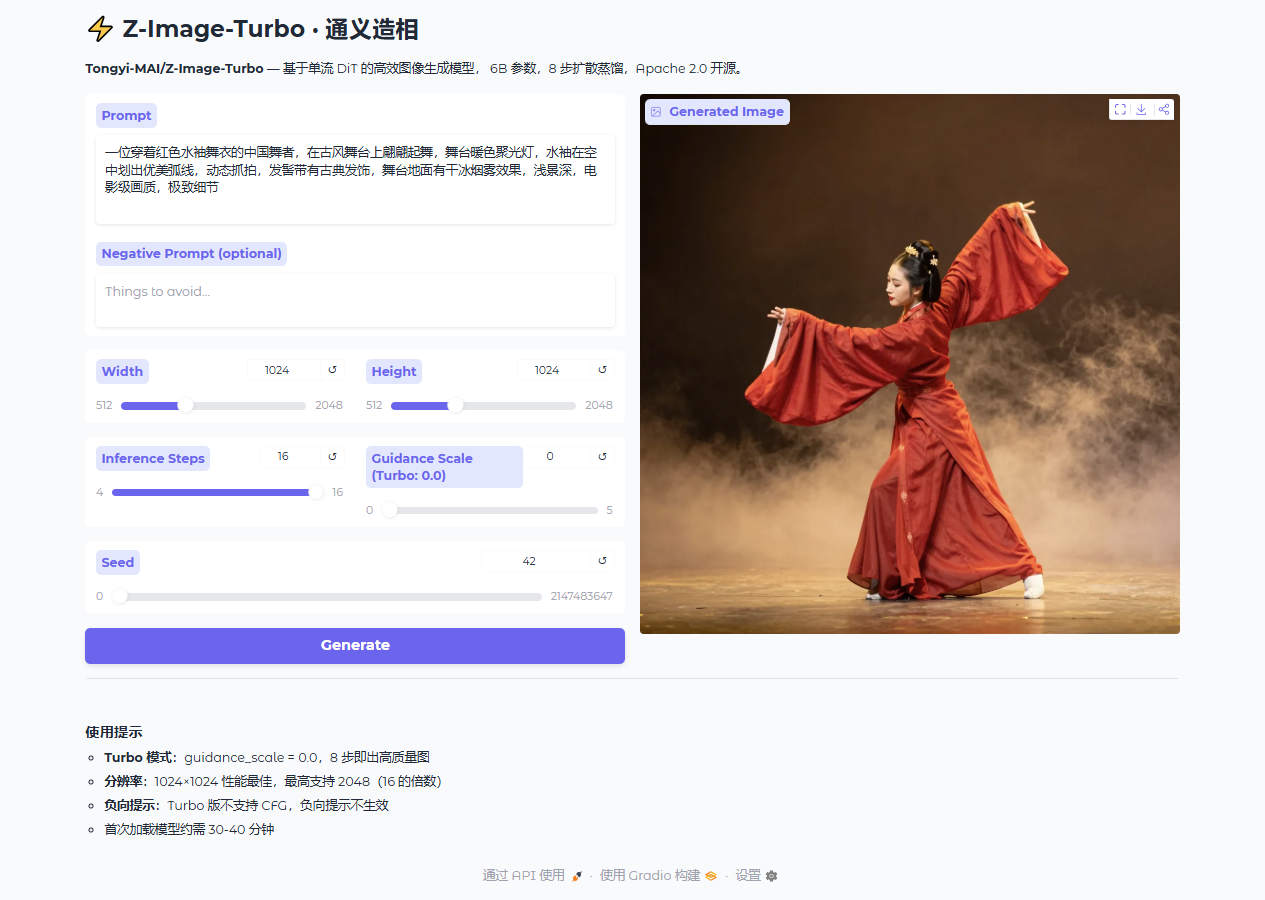


## 二、官方链接

| 类别 | 链接 |
|------|------|
| 🤗 HuggingFace | https://huggingface.co/Tongyi-MAI/Z-Image-Turbo |
| 🐙 GitHub | https://github.com/Tongyi-MAI/Z-Image |
| 📄 论文/Blog | https://tongyi-mai.github.io/Z-Image-blog/ |
| 🌐 官方资源站 | https://z-image.me/zh/resources |
| 🇨🇳 hf-mirror 镜像 | https://hf-mirror.com/Tongyi-MAI/Z-Image-Turbo |


## 三、算力推荐

| 配置等级 | 推荐 GPU | 显存要求 | 说明 |
|---------|----------|---------|------|
| **最低配置** | B1.large（24GB） | ≥ 24 GB | 8 步 1024x1024 峰值显存 ~21.67GB，勉强运行；512x512 峰值 ~19.89GB
| **流畅配置** | P1.gpu.medium（39.2GB） | ≥ 32 GB | 8 步 1024x1024 延迟 ~5.5s，支持 2048x2048 高分辨率（峰值 28.8GB） |


## 四、推理服务配置

| 配置项 | 参数值 |
|--------|--------|
| **基础镜像** | CUDA12.4-PyTorch-2.6.0 |
| **模型挂载** | `/gemini/pretrain/Z-Image-Turbo` |
| **代码目录** | `/gemini/code/` |
| **启动命令** | `bash /gemini/code/start.sh` |
| **服务端口** | 7860 |
| **访问路由** | `/` → Gradio WebUI |
| **推理引擎** | PyTorch 2.6.0 + CUDA 12.4 + diffusers 0.38.0 |


## 五、使用说明

### 5.1 WebUI 操作步骤

1. 打开推理服务地址（/），进入 Gradio WebUI 界面
2. 在「Prompt」文本框中输入图像描述（推荐英文描述，效果更佳）
3. （可选）在「Negative Prompt」中输入负向提示（Turbo 版不支持 CFG，负向提示不生效）
4. 调整生成参数：
   - **Width / Height**：512~2048，步长 64，建议 1024×1024
   - **Inference Steps**：4~16，默认 8，Turbo 模式 8 步即出高质量图
   - **Guidance Scale**：0.0~5.0，Turbo 版建议保持 0.0
   - **Seed**：0~2147483647，-1 随机，固定种子可复现
5. 点击「Generate」按钮开始生成
6. 等待生成完成后，右侧显示生成的图片，可右键保存

> ⚠️ 首次加载模型约需 15-20 分钟（后台预加载中），后续请求无需等待


In [ ]:
# 一键启动推理服务（在开发环境内使用）
!cd /gemini/code && python app.py

### 5.2 提示词格式建议

提示词建议用英文描述主体、动作、场景风格和光线等信息，Z-Image-Turbo 对中文也有较好的支持：

```
示例 1（英文·写实风格）:
  "A young Chinese woman in red Hanfu, intricate embroidery, golden phoenix headdress, 
   holding a round folding fan, night background with pagoda silhouette, neon accents"

示例 2（英文·创意风格）:
  "A ginger cat wearing a tiny wizard hat reading a spellbook, 
   warm cozy lighting, cinematic composition, highly detailed"

示例 3（中文）:
  "一只戴帽子的猫，魔法风格，暖色调，电影质感"
```

> 💡 **技巧**：Turbo 模式下 guidance_scale 保持 0.0，模型会自动匹配提示词风格；
> 如需要更强控制，可尝试提升到 1.0-2.0。


### 5.3 API 调用示例

推理服务支持通过 Gradio API 远程调用：

```python
import requests
import base64
from PIL import Image
from io import BytesIO

# 推理服务地址
SERVER_URL = "https://your-service-url.com"

# 调用 Gradio API（/api/predict）
response = requests.post(
    f"{SERVER_URL}/api/predict",
    json={
        "data": [
            "a ginger cat wearing a tiny wizard hat",  # prompt
            "",  # negative_prompt
            1024,  # width
            1024,  # height
            8,  # steps
            0.0,  # guidance_scale
            42,  # seed
        ]
    }
)

# 解析返回的图片（base64 格式）
result = response.json()
img_data = result['data'][0]  # 图片 base64 字符串
img = Image.open(BytesIO(base64.b64decode(img_data.split(',')[1])))
img.save("generated.png")
print("Image saved to generated.png")
```


### 5.4 注意事项

- **模型加载时间**：首次加载约 15-20 分钟（P1.gpu.medium），6B 参数模型初始化需要较长时间
- **离线部署**：本实现已设置 `local_files_only=True`，所有模型文件从本地路径读取，完全离线
- **冷启动**：推理服务启动后后台线程自动加载模型，无需手动触发
- **保活机制**：内置保活线程每 5 分钟 ping 本地服务，防止平台空闲超时杀进程
- **显存占用**：1024x1024 8 步推理峰值 ~21.67GB，B1.large（24GB）可运行但余量紧张
- **Turbo 模式**：guidance_scale 建议保持 0.0，Turbo 版本身已蒸馏优化，增大 CFG 可能反而降低质量
- **许可证**：Apache 2.0，可免费商用
- **分辨率**：1024×1024 性能最佳，最高支持 2048（需 64 的倍数），超过 1536 建议使用 P1 级别 GPU


## 六、模型评测结论

### 6.1 测试环境

| 项目 | 值 |
|------|------|
| **GPU** | P1.gpu.medium |
| **总显存** | 39.2 GB |
| **模型参数量** | 6B |
| **PyTorch** | 2.6.0+cu124 |
| **CUDA** | 12.4 |
| **diffusers** | 0.38.0 |

### 6.2 核心结论

- **8 步 Turbo 极速生成**：1024x1024 分辨率，P50 延迟仅 **5.4~6.7s**，适合交互式体验
- **512x512 秒级出图**：P50 延迟仅 **1.1~2.1s**，适合快速原型
- **步数弹性**：4 步 ~4.4s（快速预览），16 步 ~12.9s（精细优化）
- **显存效率**：1024x1024 峰值显存 ~21.67GB（总显存 39.2GB 的 55.3%）
- **高分辨率支持**：2048x2048 峰值显存 28.8GB，需 P1 级别 GPU
- **提示词复杂度影响小**：短/中/长提示间延迟差异 < 1.3s（1024x1024）

> 📋 完整的性能评测数据详见 `测试报告/zimage-turbo-project/zimage_turbo_benchmark_result.json`
